# Physical Aggregated Data Analysis

## Load Dependencies

In [51]:
%%capture
%pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels jupyterlab

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [71]:
df = pd.read_csv('./data/phys_agg_30s.csv')
df.head()

,bucket,system_id,prop_key,asset_id,avg_value,max_value,min_value,stddev_value,num_measurements,num_attacks,attack_types
0,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_1,31.8,178.0,0.0,61.926121,10,0,['normal']
1,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_2,0.0,0.0,0.0,0.000000,10,0,['normal']
2,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_3,0.0,0.0,0.0,0.000000,10,0,['normal']
3,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_4,0.0,0.0,0.0,0.000000,10,0,['normal']
4,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_5,0.0,0.0,0.0,0.000000,10,0,['normal']


In [67]:
df.dtypes

bucket               object
system_id            object
prop_key             object
asset_id             object
avg_value           float64
max_value           float64
min_value           float64
stddev_value        float64
num_measurements      int64
num_attacks           int64
attack_types         object
dtype: object

In [80]:
# labels least to most severe
y_labels = ['normal', 'anomaly', 'scan', 'dos', 'mitm', 'physical fault']

# map attack_types to a single attack, taking the most severe label
def map_attack_type(attack_types):
    if 'physical fault' in attack_types.lower():
        return 'physical fault'
    elif 'mitm' in attack_types.lower():
        return 'mitm'
    elif 'dos' in attack_types.lower():
        return 'dos'
    elif 'scan' in attack_types.lower():
        return 'scan'
    elif 'anomaly' in attack_types.lower():
        return 'anomaly'
    else:
        return 'normal'
    
df['attack_type'] = df['attack_types'].apply(map_attack_type)
df['attack_type_num'] = df['attack_type'].apply(lambda x: y_labels.index(x)).astype(float)
df[['attack_type', 'attack_type_num']].value_counts()

attack_type     attack_type_num
normal          0.0                10440
mitm            4.0                 1760
physical fault  5.0                 1280
dos             3.0                  760
scan            2.0                  520
Name: count, dtype: int64

Pivot Dataset by bucket and system_id



In [60]:
# Pivot Dataset by bucket and system_id
pivot_df = df.pivot_table(index='bucket', columns='asset_id', aggfunc='first', values=['avg_value', 'min_value', 'max_value', 'stddev_value'])
pivot_df.columns = [f'{asset_id.replace("testbed_system_1_", "")}_{stat}' for stat, asset_id in pivot_df.columns]
pivot_df.head()




,Flow_sensor_Flow_sensor_1_avg_value,Flow_sensor_Flow_sensor_2_avg_value,Flow_sensor_Flow_sensor_3_avg_value,Flow_sensor_Flow_sensor_4_avg_value,Pump_Pump_1_avg_value,Pump_Pump_2_avg_value,Pump_Pump_3_avg_value,Pump_Pump_4_avg_value,Pump_Pump_5_avg_value,Pump_Pump_6_avg_value,...,Valv_Valv_20_stddev_value,Valv_Valv_21_stddev_value,Valv_Valv_22_stddev_value,Valv_Valv_3_stddev_value,Valv_Valv_4_stddev_value,Valv_Valv_5_stddev_value,Valv_Valv_6_stddev_value,Valv_Valv_7_stddev_value,Valv_Valv_8_stddev_value,Valv_Valv_9_stddev_value
bucket,,,,,,,,,,,,,,,,,,,,,
2021-04-09 11:30:30+00:00,0.0,0.0,0.0,0.0,0.400000,0.4,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-04-09 11:31:00+00:00,0.0,0.0,0.0,0.0,1.000000,1.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-04-09 11:31:30+00:00,0.0,0.0,0.0,0.0,1.000000,1.0,0.0,0.066667,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-04-09 11:32:00+00:00,0.0,0.0,0.0,0.0,0.733333,0.0,0.0,1.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-04-09 11:32:30+00:00,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.900000,0.0,0.0,...,0.345746,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
pivot_df.describe()

,Flow_sensor_Flow_sensor_1_avg_value,Flow_sensor_Flow_sensor_2_avg_value,Flow_sensor_Flow_sensor_3_avg_value,Flow_sensor_Flow_sensor_4_avg_value,Pump_Pump_1_avg_value,Pump_Pump_2_avg_value,Pump_Pump_3_avg_value,Pump_Pump_4_avg_value,Pump_Pump_5_avg_value,Pump_Pump_6_avg_value,...,Valv_Valv_20_stddev_value,Valv_Valv_21_stddev_value,Valv_Valv_22_stddev_value,Valv_Valv_3_stddev_value,Valv_Valv_4_stddev_value,Valv_Valv_5_stddev_value,Valv_Valv_6_stddev_value,Valv_Valv_7_stddev_value,Valv_Valv_8_stddev_value,Valv_Valv_9_stddev_value
count,369.000000,369.000000,369.0,369.000000,369.000000,369.000000,369.0,369.000000,369.000000,369.000000,...,369.000000,369.0,369.000000,369.0,369.0,369.0,369.0,369.0,369.0,369.0
mean,1480.700736,1525.925926,0.0,1357.790278,0.358809,0.229059,0.0,0.215266,0.370577,0.381572,...,0.070508,0.0,0.064463,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,1788.902971,1829.589209,0.0,1701.491805,0.430887,0.377997,0.0,0.369078,0.448187,0.457945,...,0.159677,0.0,0.158304,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.000000,0.000000,0.0,130.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,4000.000000,3866.666667,0.0,2805.566667,0.900000,0.411765,0.0,0.300000,1.000000,0.966667,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,4000.000000,4000.000000,0.0,4682.666667,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,...,0.508548,0.0,0.508548,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
pivot_df.columns[pivot_df.isna().any()]

Index([], dtype='object')

In [56]:
pivot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Columns: 162 entries, bucket to attack_types
dtypes: float64(160), object(2)
memory usage: 467.1+ KB


['Valv_Valv_1_avg_value', 'Valv_Valv_10_avg_value', 'Valv_Valv_11_avg_value', 'Valv_Valv_12_avg_value', 'Valv_Valv_13_avg_value', 'Valv_Valv_14_avg_value', 'Valv_Valv_15_avg_value', 'Valv_Valv_16_avg_value', 'Valv_Valv_17_avg_value', 'Valv_Valv_18_avg_value', 'Valv_Valv_19_avg_value', 'Valv_Valv_2_avg_value', 'Valv_Valv_20_avg_value', 'Valv_Valv_21_avg_value', 'Valv_Valv_22_avg_value', 'Valv_Valv_3_avg_value', 'Valv_Valv_4_avg_value', 'Valv_Valv_5_avg_value', 'Valv_Valv_6_avg_value', 'Valv_Valv_7_avg_value', 'Valv_Valv_8_avg_value', 'Valv_Valv_9_avg_value', 'Valv_Valv_1_max_value', 'Valv_Valv_10_max_value', 'Valv_Valv_11_max_value', 'Valv_Valv_12_max_value', 'Valv_Valv_13_max_value', 'Valv_Valv_14_max_value', 'Valv_Valv_15_max_value', 'Valv_Valv_16_max_value', 'Valv_Valv_17_max_value', 'Valv_Valv_18_max_value', 'Valv_Valv_19_max_value', 'Valv_Valv_2_max_value', 'Valv_Valv_20_max_value', 'Valv_Valv_21_max_value', 'Valv_Valv_22_max_value', 'Valv_Valv_3_max_value', 'Valv_Valv_4_max_value'

C:\Users\jd02_\AppData\Local\Temp\ipykernel_18648\2324365551.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valve_columns_data['attack'] = df.groupby('bucket')['attack_type_num'].first().values


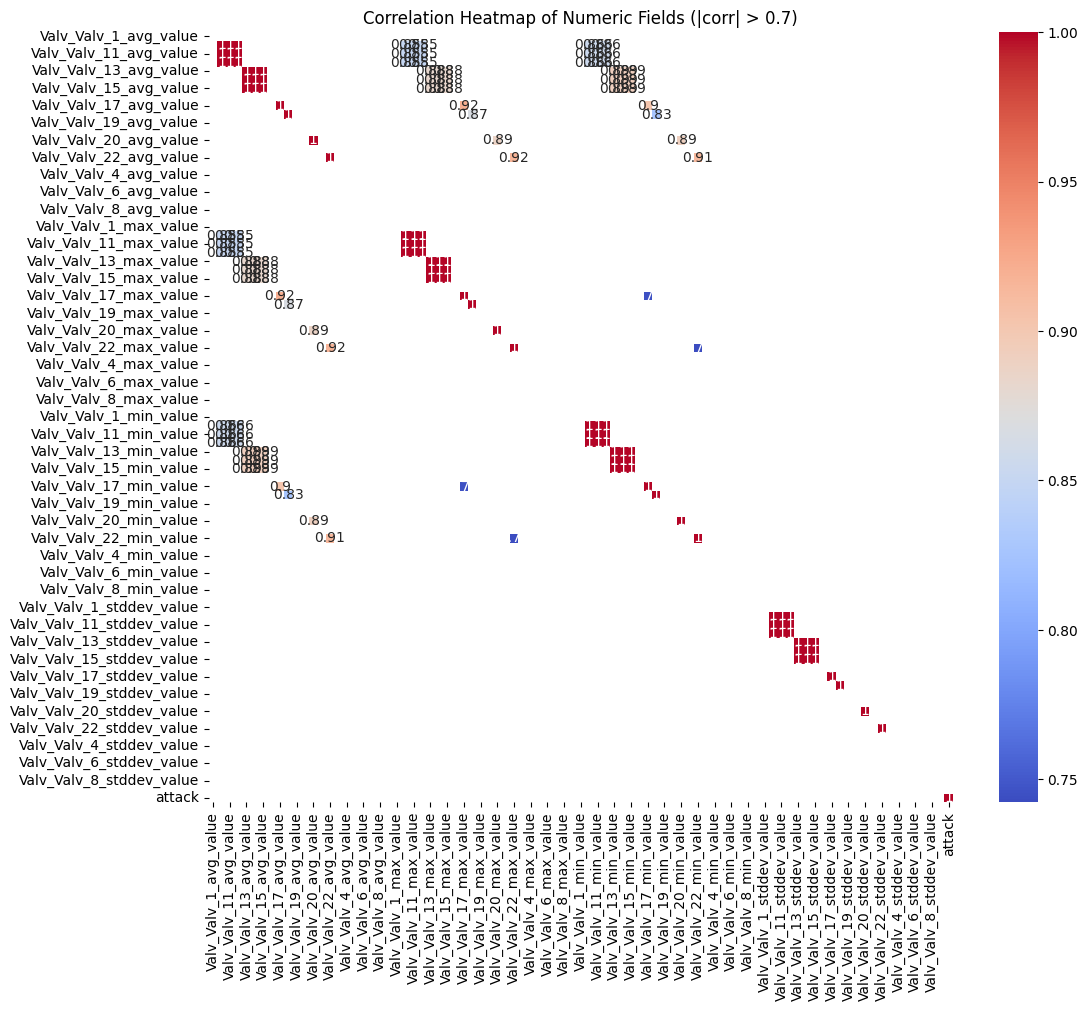

In [81]:
numeric_fields = pivot_df.select_dtypes(include=['float64', 'int64'])
valv_columns = [col for col in numeric_fields.columns if col.__contains__('Valv')]

print(valv_columns)
valve_columns_data = numeric_fields[valv_columns]
valve_columns_data['attack'] = df.groupby('bucket')['attack_type_num'].first().values
# Correlation Heatmap of Numeric Fields with correlation values > 0.7 or < -0.7
plt.figure(figsize=(12, 10))
corr = valve_columns_data.corr()
high_corr = corr[(np.abs(corr) > 0.7) ]
sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Fields (|corr| > 0.7)')
plt.show()

['Pump_Pump_1_avg_value', 'Pump_Pump_2_avg_value', 'Pump_Pump_3_avg_value', 'Pump_Pump_4_avg_value', 'Pump_Pump_5_avg_value', 'Pump_Pump_6_avg_value', 'Pump_Pump_1_max_value', 'Pump_Pump_2_max_value', 'Pump_Pump_3_max_value', 'Pump_Pump_4_max_value', 'Pump_Pump_5_max_value', 'Pump_Pump_6_max_value', 'Pump_Pump_1_min_value', 'Pump_Pump_2_min_value', 'Pump_Pump_3_min_value', 'Pump_Pump_4_min_value', 'Pump_Pump_5_min_value', 'Pump_Pump_6_min_value', 'Pump_Pump_1_stddev_value', 'Pump_Pump_2_stddev_value', 'Pump_Pump_3_stddev_value', 'Pump_Pump_4_stddev_value', 'Pump_Pump_5_stddev_value', 'Pump_Pump_6_stddev_value']


C:\Users\jd02_\AppData\Local\Temp\ipykernel_18648\2681948105.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pump_columns_data['attack'] = df.groupby('bucket')['attack_type_num'].first().values


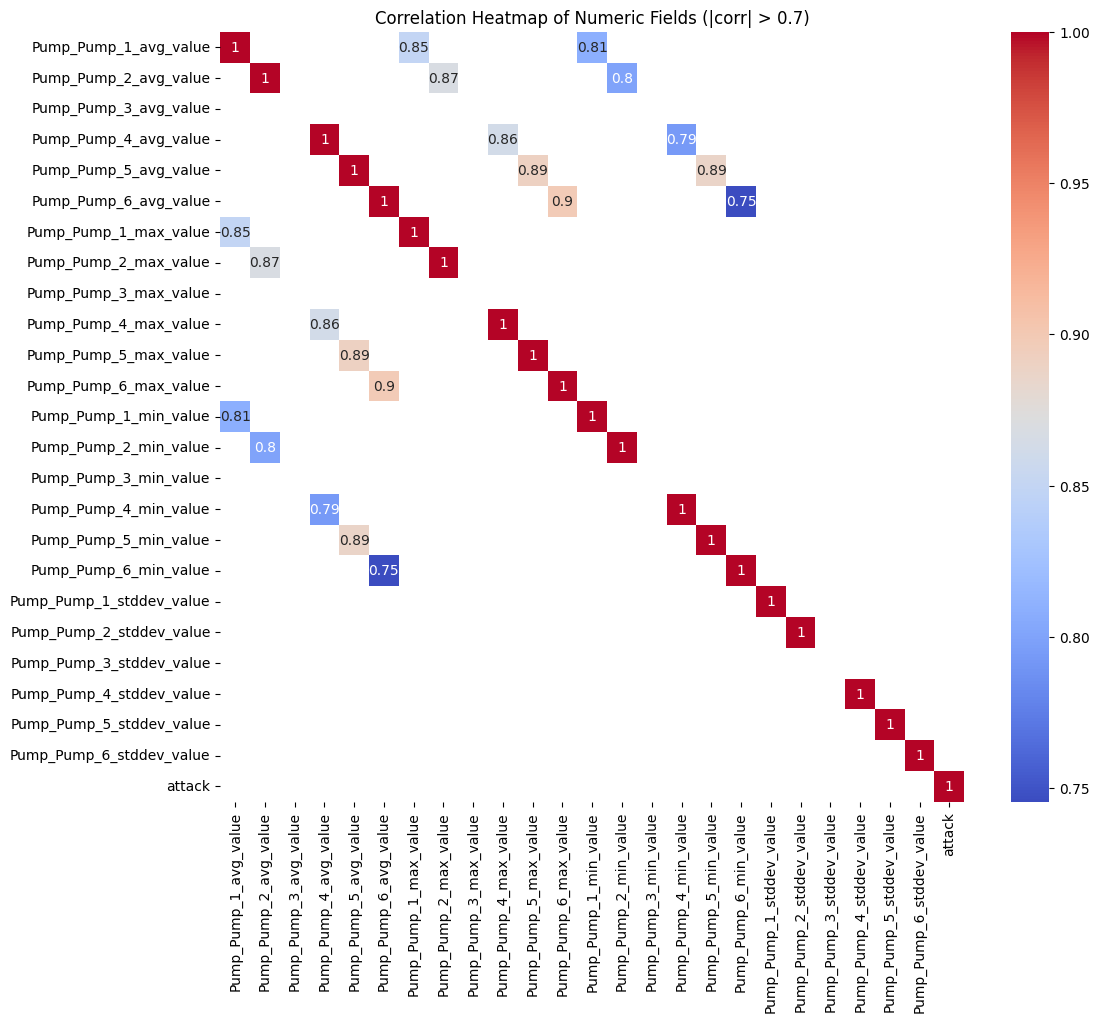

In [82]:
pump_columns = [col for col in numeric_fields.columns if col.__contains__('Pump')]
print(pump_columns)
pump_columns_data = numeric_fields[pump_columns]
pump_columns_data['attack'] = df.groupby('bucket')['attack_type_num'].first().values
# Correlation Heatmap of Numeric Fields with correlation values > 0.7 or < -0.7
plt.figure(figsize=(12, 10))
corr = pump_columns_data.corr()
high_corr = corr[(np.abs(corr) > 0.7) ]
sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Fields (|corr| > 0.7)')
plt.show()

['Tank_Tank_1_avg_value', 'Tank_Tank_2_avg_value', 'Tank_Tank_3_avg_value', 'Tank_Tank_4_avg_value', 'Tank_Tank_5_avg_value', 'Tank_Tank_6_avg_value', 'Tank_Tank_7_avg_value', 'Tank_Tank_8_avg_value', 'Tank_Tank_1_max_value', 'Tank_Tank_2_max_value', 'Tank_Tank_3_max_value', 'Tank_Tank_4_max_value', 'Tank_Tank_5_max_value', 'Tank_Tank_6_max_value', 'Tank_Tank_7_max_value', 'Tank_Tank_8_max_value', 'Tank_Tank_1_min_value', 'Tank_Tank_2_min_value', 'Tank_Tank_3_min_value', 'Tank_Tank_4_min_value', 'Tank_Tank_5_min_value', 'Tank_Tank_6_min_value', 'Tank_Tank_7_min_value', 'Tank_Tank_8_min_value', 'Tank_Tank_1_stddev_value', 'Tank_Tank_2_stddev_value', 'Tank_Tank_3_stddev_value', 'Tank_Tank_4_stddev_value', 'Tank_Tank_5_stddev_value', 'Tank_Tank_6_stddev_value', 'Tank_Tank_7_stddev_value', 'Tank_Tank_8_stddev_value']


C:\Users\jd02_\AppData\Local\Temp\ipykernel_18648\387776481.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tank_columns_data['attack'] = df.groupby('bucket')['attack_type_num'].first().values


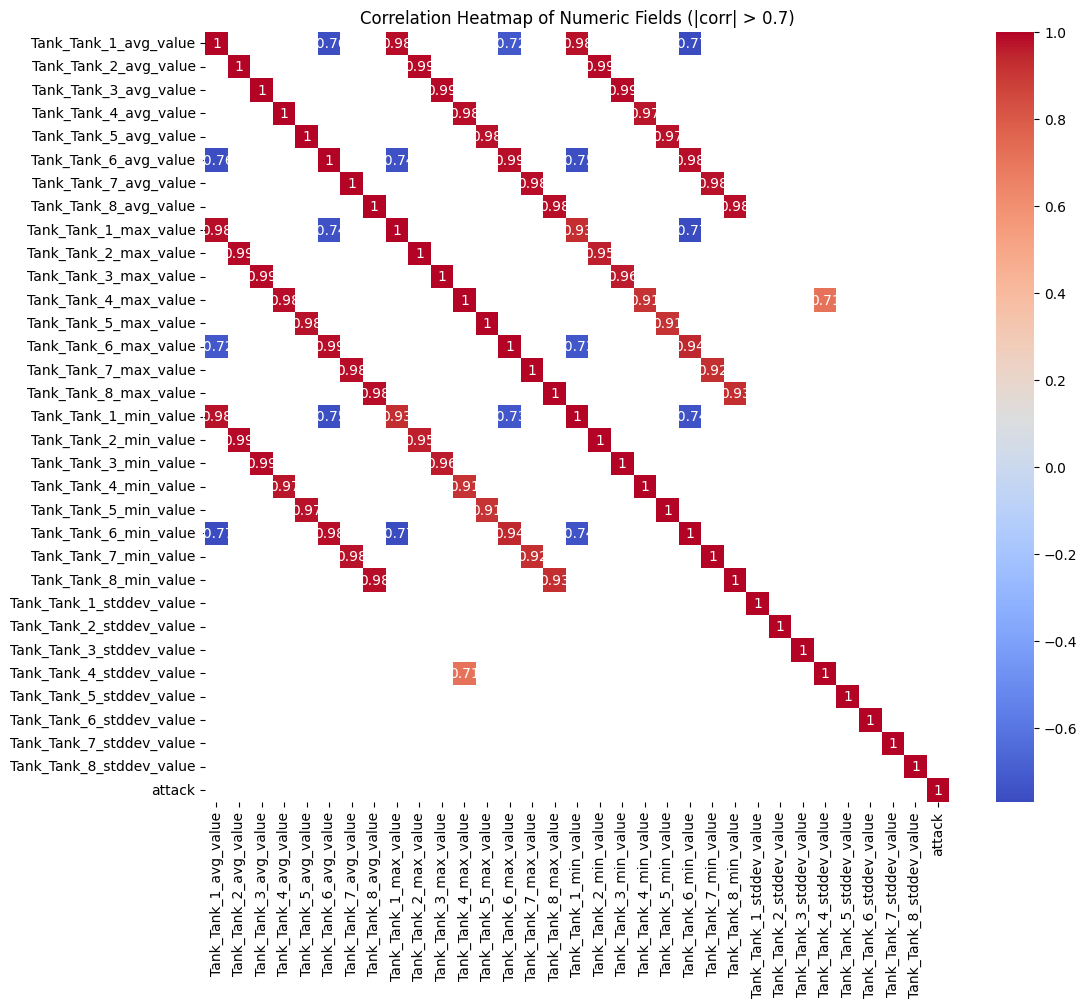

In [83]:
tank_columns = [col for col in numeric_fields.columns if col.__contains__('Tank')]
print(tank_columns)
tank_columns_data = numeric_fields[tank_columns]
tank_columns_data['attack'] = df.groupby('bucket')['attack_type_num'].first().values
# Correlation Heatmap of Numeric Fields with correlation values > 0.7 or < -0.7
plt.figure(figsize=(12, 10))
corr = tank_columns_data.corr()
high_corr = corr[(np.abs(corr) > 0.7) ]
sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Fields (|corr| > 0.7)')
plt.show()